In [4]:
#import libraries
print("Karthick N 24BAD055")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

Karthick N 24BAD055


In [5]:
# Load dataset
ratings = pd.read_csv("dataset/ratings.csv")
movies = pd.read_csv("dataset/movies.csv")

data = pd.merge(ratings, movies, on="movieId")

data.rename(columns={
    "userId": "user_id",
    "movieId": "movie_id",
    "rating": "rating",
    "timestamp": "timestamp",
    "title": "title"
}, inplace=True)

data.head()

,user_id,movie_id,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [6]:
#Data Inspection
print("Shape:", data.shape)
print("\nMissing values:\n", data.isnull().sum())

print("\nUnique Users:", data['user_id'].nunique())
print("Unique Movies:", data['movie_id'].nunique())

data.describe()

Shape: (100836, 6)

Missing values:
 user_id      0
movie_id     0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

Unique Users: 610
Unique Movies: 9724


,user_id,movie_id,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [7]:
#Create user-item matrix
user_item_matrix = data.pivot_table(index='user_id', columns='title', values='rating')

user_item_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Handling missing values 
user_item_matrix_filled = user_item_matrix.fillna(0)
user_item_matrix_filled.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
#Compute cosine similarity
user_similarity = cosine_similarity(user_item_matrix_filled)

user_similarity_df = pd.DataFrame(user_similarity, 
                                  index=user_item_matrix.index, 
                                  columns=user_item_matrix.index)

user_similarity_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [10]:
#Find top-N similar users
def get_similar_users(user_id, n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]
    return similar_users

# Example
get_similar_users(1, 5)

user_id
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
Name: 1, dtype: float64

In [11]:
#Predict ratings
def predict_ratings(user_id):
    similar_users = get_similar_users(user_id, 5)
    similar_users_ids = similar_users.index
    
    similar_ratings = user_item_matrix_filled.loc[similar_users_ids]
    
    weighted_sum = np.dot(similar_users.values, similar_ratings)
    sim_sum = np.sum(similar_users.values)
    
    predicted_ratings = weighted_sum / sim_sum
    
    return pd.Series(predicted_ratings, index=user_item_matrix.columns)

# Example
predicted = predict_ratings(1)
predicted.head()

title
'71 (2014)                                 0.0
'Hellboy': The Seeds of Creation (2004)    0.0
'Round Midnight (1986)                     0.0
'Salem's Lot (2004)                        0.0
'Til There Was You (1997)                  0.0
dtype: float64

In [12]:
#Top-N recommendations
def recommend_movies(user_id, n=5):
    predicted_ratings = predict_ratings(user_id)
    
    already_rated = user_item_matrix.loc[user_id].dropna().index
    
    recommendations = predicted_ratings.drop(already_rated)
    
    top_recommendations = recommendations.sort_values(ascending=False).head(n)
    
    return top_recommendations

# Example
recommend_movies(1, 5)

title
Aliens (1986)                        4.801002
Hunt for Red October, The (1990)     4.298950
Blade Runner (1982)                  4.004742
Terminator 2: Judgment Day (1991)    4.003711
Die Hard (1988)                      4.000000
dtype: float64

In [13]:
#Evalation metrices
# Prediction matrix
predicted_matrix = np.dot(user_similarity, user_item_matrix_filled) / np.array([np.abs(user_similarity).sum(axis=1)]).T

actual = user_item_matrix_filled.values.flatten()
predicted = predicted_matrix.flatten()

# Ignore zero values
mask = actual > 0
actual = actual[mask]
predicted = predicted[mask]

rmse = sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 3.0732205951143596
MAE: 2.8962676149211024


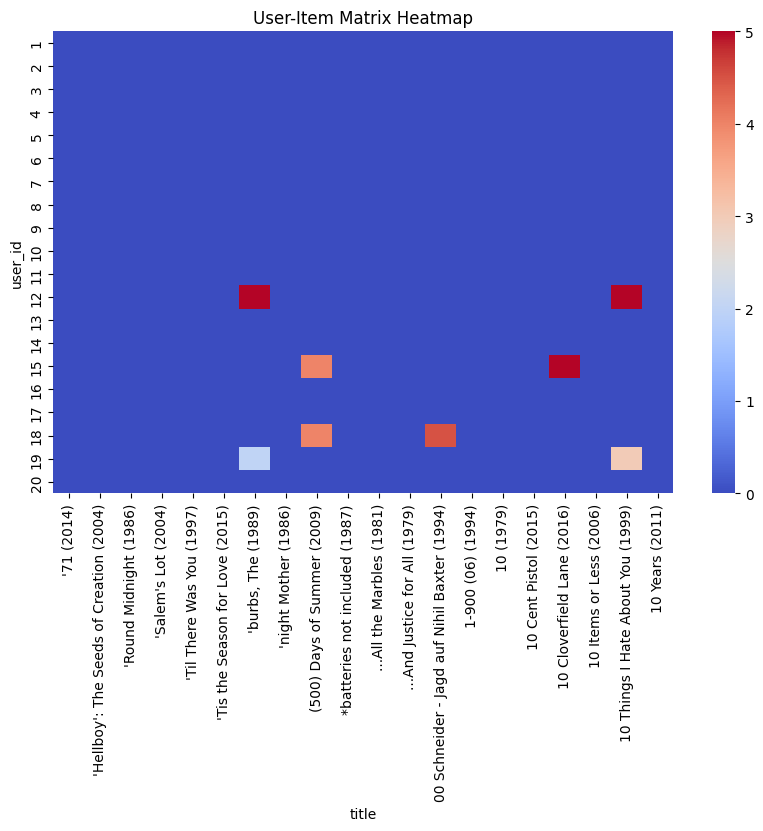

In [14]:
#Visualization
#User-item heatmap
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20], cmap="coolwarm")
plt.title("User-Item Matrix Heatmap")
plt.show()

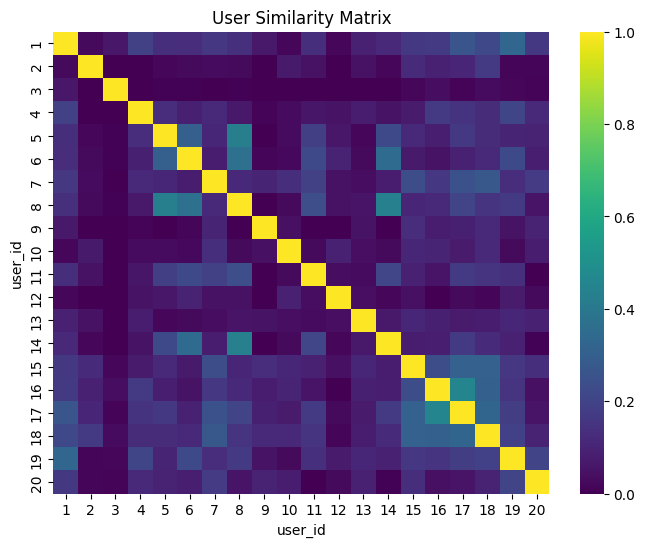

In [18]:
#Similarity heatmap
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap="viridis")
plt.title("User Similarity Matrix")
plt.show()

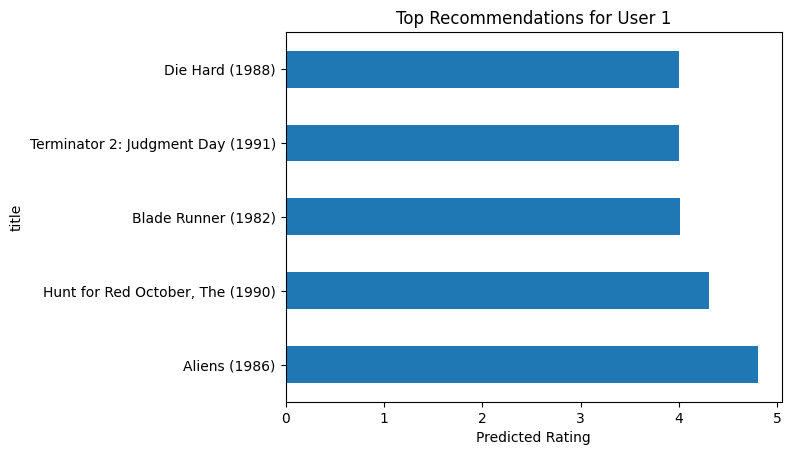

In [16]:
#Recommendation heatmap
user_id = 1
recs = recommend_movies(user_id, 5)

recs.plot(kind='barh')
plt.title(f"Top Recommendations for User {user_id}")
plt.xlabel("Predicted Rating")
plt.show()